#### ANÁLISE DO DATASET:

##### IMDB movies dataset
Link:
https://www.kaggle.com/datasets/ashpalsingh1525/imdb-movies-dataset?resource=download

O cliente quer entender dois pontos antes de decidir onde investir:
1. o que faz um filme ser bem aceito pelo público;
2. o que faz um filme gerar retorno financeiro;
e, principalmente, onde essas duas dimensões não caminham juntas.
A análise não pretende provar causalidade. Correlação e diferenças entre grupos serão usadas como evidências para levantar hipóteses de negócio.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

ARQUIVO = "imdb_movies.csv"

df = pd.read_csv(ARQUIVO)



print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")
display(df.head())


Linhas: 10,178
Colunas: 12


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.00,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,"75,000,000.00","271,616,668.00",AU
1,Avatar: The Way of Water,12/15/2022,78.00,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,"460,000,000.00","2,316,794,914.00",AU
2,The Super Mario Bros. Movie,04/05/2023,76.00,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,"100,000,000.00","724,459,031.00",AU
3,Mummies,01/05/2023,70.00,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian","12,300,000.00","34,200,000.00",AU
4,Supercell,03/17/2023,61.00,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,"77,000,000.00","340,941,958.60",US


In [4]:
df.columns = df.columns.str.strip()
print(columns := df.columns.tolist())

['names', 'date_x', 'score', 'genre', 'overview', 'crew', 'orig_title', 'status', 'orig_lang', 'budget_x', 'revenue', 'country']


In [5]:

# Padronização básica
df.columns = df.columns.str.strip()

for col in ["score", "budget_x", "revenue"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["names", "genre", "crew", "orig_title", "status", "orig_lang", "country"]:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()

# Datas
df["date"] = pd.to_datetime(df["date_x"].astype("string").str.strip(),
                            errors="coerce", format="%m/%d/%Y")
df["year"] = df["date"].dt.year

# Variáveis derivadas
df["log_budget"] = np.log10(df["budget_x"].where(df["budget_x"] > 0))
df["log_revenue"] = np.log10(df["revenue"].where(df["revenue"] > 0))

print("Tipos:")
display(df.dtypes)


Tipos:


names                  string
date_x                    str
score                 float64
genre                  string
overview                  str
crew                   string
orig_title             string
status                 string
orig_lang              string
budget_x              float64
revenue               float64
country                string
date           datetime64[us]
year                    int32
log_budget            float64
log_revenue           float64
dtype: object

#### 1. Além do gênero, o que mais parece influenciar a nota que um filme recebe do público?

In [6]:

# Correlação entre as principais variáveis numéricas e a nota
correlacoes = (
    df[["score", "budget_x", "revenue", "year"]]
    .corr(numeric_only=True)["score"]
    .drop("score")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

display(correlacoes.to_frame("correlacao_com_nota"))

# Número de filmes por faixa de nota
df["faixa_nota"] = pd.cut(
    df["score"],
    bins=[-np.inf, 59.99, 69.99, 79.99, np.inf],
    labels=["< 60", "60–69", "70–79", "≥ 80"]
)

display(df["faixa_nota"].value_counts().sort_index())


,correlacao_com_nota
budget_x,-0.24
year,-0.15
revenue,0.10


faixa_nota
< 60     2699
60–69    4184
70–79    2864
≥ 80      431
Name: count, dtype: int64

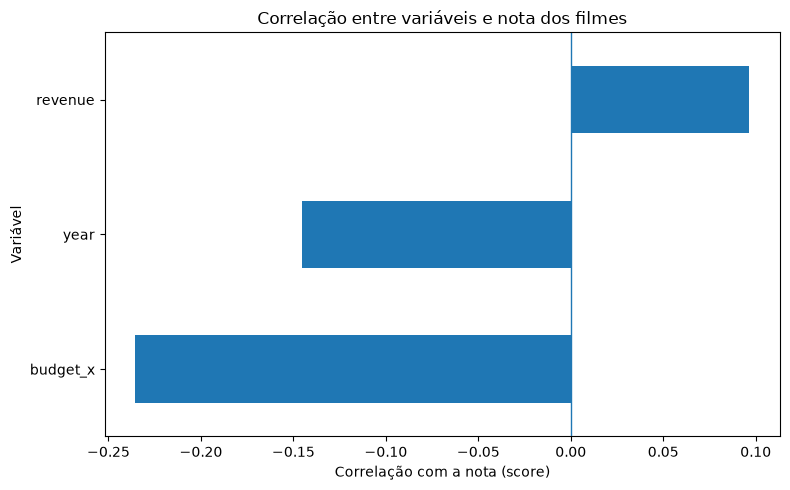

In [7]:
import matplotlib.pyplot as plt

# Gráfico da correlação das variáveis com a nota
plt.figure(figsize=(8, 5))

correlacoes.sort_values().plot(
    kind="barh"
)

plt.axvline(0, linewidth=1)
plt.title("Correlação entre variáveis e nota dos filmes")
plt.xlabel("Correlação com a nota (score)")
plt.ylabel("Variável")

plt.tight_layout()
plt.show()

,media,mediana,filmes
genre,,,
History,69.16,71.00,422
War,69.07,70.00,282
Animation,68.99,70.00,1468
Music,68.71,70.00,277
Western,68.01,68.00,131
Family,66.21,67.00,1407
Drama,65.95,68.00,3812
Fantasy,65.72,67.00,1382
Adventure,65.27,66.00,1890


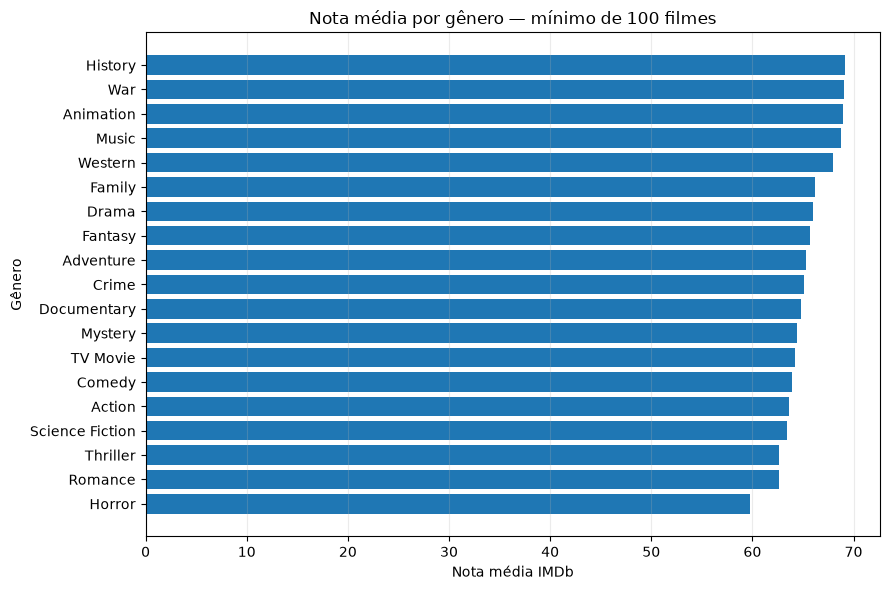

In [8]:

# Gênero: separar os gêneros que estão juntos em uma mesma célula
generos = (
    df[["genre", "score"]]
    .dropna(subset=["genre", "score"])
    .assign(genre=lambda x: x["genre"].str.split(r",\s*"))
    .explode("genre")
)

generos["genre"] = generos["genre"].str.replace("\xa0", " ", regex=False).str.strip()

resumo_genero = (
    generos.groupby("genre")["score"]
    .agg(media="mean", mediana="median", filmes="count")
    .query("filmes >= 100")
    .sort_values("media", ascending=False)
)

display(resumo_genero)

# Gráfico principal
graf_genero = resumo_genero.sort_values("media")

plt.figure(figsize=(9, 6))
plt.barh(graf_genero.index, graf_genero["media"])
plt.xlabel("Nota média IMDb")
plt.ylabel("Gênero")
plt.title("Nota média por gênero — mínimo de 100 filmes")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
